# Images and Computer Vision

**Author:** Alexander Michels

Imagery is one of the most ubiquitous types of data and yet it is underutilized because it can be time-consuming to analyze. This notebook walks through the basics of how a computer "sees" an image and provides a gentle introduction to computer vision.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from transformers.image_utils import load_image

/home/dal384425/Documents/GitHubRepos/I-GUIDEChampion-ML4StreetViewImagery/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## How Computers "See"

A computer sees an image as a list of arrays of numbers. Usually from 0-1 or 0-255. Each array represents a different "band" of color (most commonly Red, Blue and Green) and the values describe how much of that color is present.

Each cell in the array represents a "pixel" in the image. If you've ever heard of an image being "pixelated" this just means that you can see the individual pixels that make up the image. 

Our brains make sense of the cells of light to identify what is happening in the imagery, but let's explore how a computer "sees" an image. We will start with some random noise, just random numbers.

In [2]:
random_noise = np.random.rand(640, 640)
random_noise

array([[0.18222364, 0.61430413, 0.87285729, ..., 0.83585328, 0.81842737,
        0.11509581],
       [0.21027759, 0.21859124, 0.96788253, ..., 0.87893253, 0.4923337 ,
        0.4716174 ],
       [0.51633046, 0.91619693, 0.01756753, ..., 0.06085734, 0.98379391,
        0.07952817],
       ...,
       [0.89507537, 0.60865737, 0.72817045, ..., 0.2118525 , 0.94961409,
        0.07498657],
       [0.21747935, 0.75940823, 0.22774929, ..., 0.68906051, 0.08262908,
        0.55194391],
       [0.13887488, 0.63209443, 0.96710591, ..., 0.30042896, 0.30680043,
        0.45314734]], shape=(640, 640))

Since this has only one "band" of color we will treat this data as grayscale. Let's plot it that way!

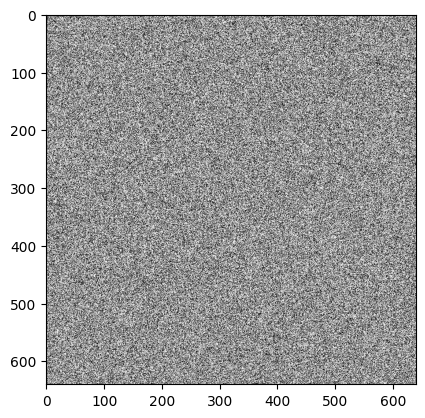

In [3]:
fig, ax = plt.subplots()
ax.imshow(np.asarray(random_noise), cmap="Greys")

Alternatively, we can generate random noise along 3 bands representing Red, Green, and Blue!

Notice in the code below we never specify RGB or to use a certain color for a certain band of our data. By default, imshow treats data in this format as an RGB image (or RGBA if there are 4 bands with A corresponding to the transparency).

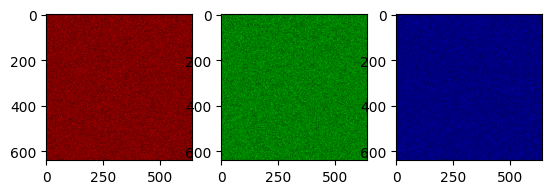

In [4]:
rgb_noise = np.random.rand(640, 640, 3)
fig, axes = plt.subplots(ncols=3)
for i in range(3):  # for each of the three bands: RGB
    tmp = np.zeros(rgb_noise.shape, dtype='float')
    tmp[:,:,i] = rgb_noise[:,:,i]
    axes[i].imshow(tmp)

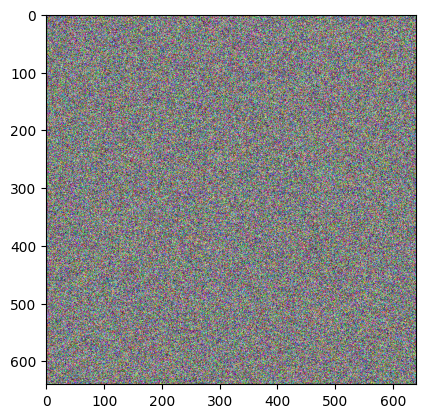

In [5]:
fig, ax = plt.subplots()
ax.imshow(rgb_noise)

## Working with Real Imagery

That's enough fun with random noise though, let's load a real image! This is a street-view image captured by Google.

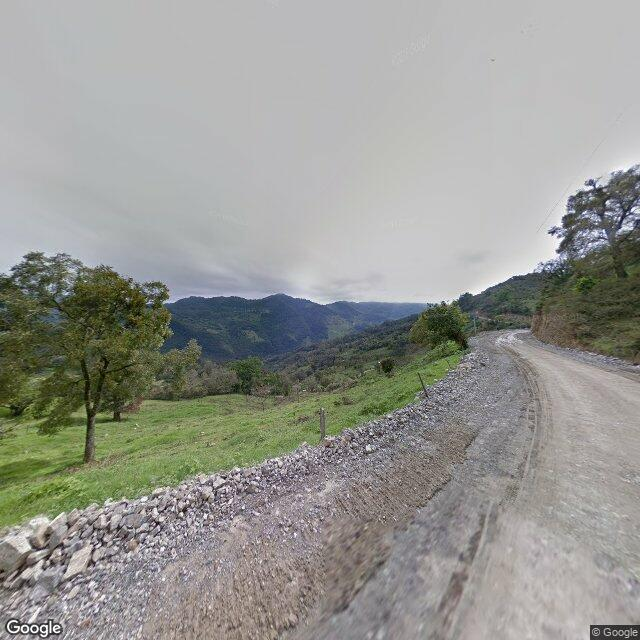

In [6]:
svimage = load_image(str(Path("data/kaggle-samples/0.png")))
svimage

We can similarly split our image into its corresponding RGB bands:

In [7]:
bands = svimage.split()
bands

(<PIL.Image.Image image mode=L size=640x640>,
 <PIL.Image.Image image mode=L size=640x640>,
 <PIL.Image.Image image mode=L size=640x640>)

Then plot each band seperately again!

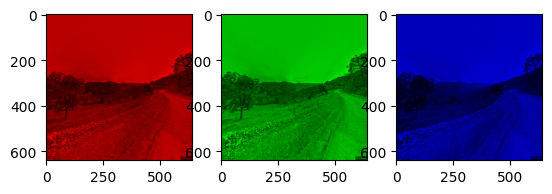

In [8]:
fig, axes = plt.subplots(ncols=3)
for i in range(3):  # for each of the three bands: RGB
    tmp = np.zeros(np.asarray(svimage).shape, dtype='int')
    tmp[:,:,i] = bands[i]
    axes[i].imshow(tmp)

## A Naive Approach to Computer Vision

Now that we understand how a computer 'sees' images, how can we turn that 'vision' into actionable insights?

One approach would be to apply simple rules, but it runs into issues. for example, we can ask "how much green is in this image?" to explore green space.

In [9]:
# simple test for enough "green"
green_threshold = 0  # any amount of green
other_threshold = 100  # not too much of the other stuff!

band_arrays = [np.asarray(bands[i]) for i in range(3)]  # convert to numpy!

green_space = np.zeros([np.asarray(svimage).shape[0], np.asarray(svimage).shape[1]], dtype='int') # let's make a temp image we will use to keep track of our classes!
for x in range(np.asarray(svimage).shape[0]):
    for y in range(np.asarray(svimage).shape[1]):  # iterate through each pixel!
        # let's define a simple rule for "green enough"
        if band_arrays[1][x][y] > green_threshold:  # if there's enough green
            if (band_arrays[0][x][y] < other_threshold) and (band_arrays[2][x][y] < other_threshold):
                green_space[x][y] = 255  # our imagery is 0-255 so we will use 255 as our "yes"

This process creates a "mask". Our mask tells us where we have identified green space (with a 255) and where we haven't (0).

In [10]:
green_space

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0, 255,   0, ..., 255, 255, 255],
       [255,   0,   0, ..., 255, 255, 255]], shape=(640, 640))

We can directly apply our mask as the transparency band of our image: only the green stuff with be visible!

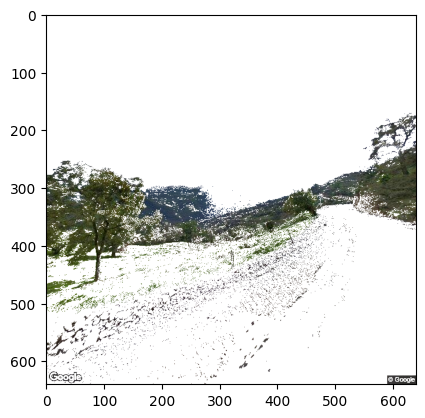

In [11]:
# apply the tmp array (our mask) as the opacity:
tmp = np.zeros([np.asarray(svimage).shape[0], np.asarray(svimage).shape[1], 4], dtype='int')  # 4th band is alpha (transparency)
for i in range(3):
    tmp[:,:,i] = bands[i]
tmp[:,:,3] = green_space
plt.imshow(tmp)

Feel free to adjust the values and write your own basic pixel-based rules to fine-tune this approach!

This approach doesn't work that well even with this image with lots of green things that are green space, but let's see how it works with a green thing that isn't green space!

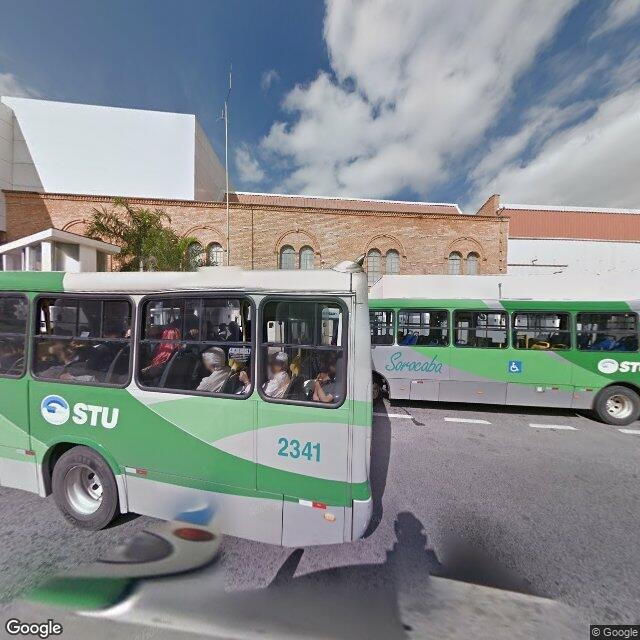

In [12]:
svimage2 = load_image(str(Path("data/kaggle-samples/2.png")))
svimage2

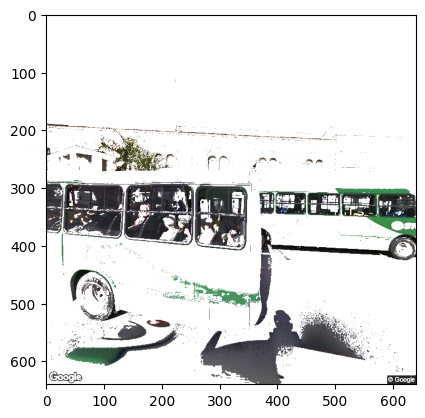

In [13]:
# simple test for enough "green"
green_threshold = 0
other_threshold = 100

bands2 = svimage2.split()
band_arrays2 = [np.asarray(bands2[i]) for i in range(3)]  # convert to numpy!

green_space = np.zeros([np.asarray(svimage2).shape[0], np.asarray(svimage2).shape[1]], dtype='int') # let's make a temp image we will use to keep track of our classes!
for x in range(np.asarray(svimage2).shape[0]):
    for y in range(np.asarray(svimage2).shape[1]):  # iterate through each pixel!
        # let's define a simple rule for "green enough"
        if band_arrays2[1][x][y] > green_threshold:  # if there's enough green
            if (band_arrays2[0][x][y] < other_threshold) and (band_arrays2[2][x][y] < other_threshold):
                green_space[x][y] = 255
# apply the tmp array (our mask) as the opacity:
tmp = np.zeros([np.asarray(svimage2).shape[0], np.asarray(svimage2).shape[1], 4], dtype='int')  # 4th band is alpha (transparency)
for i in range(3):
    tmp[:,:,i] = bands2[i]
tmp[:,:,3] = green_space
plt.imshow(tmp)

The paint on those buses definitely won't count as green space! 

Machine Learning and AI can help us come up with more sophisticated rules to classify imagery and detect imagery within them. We will explore the basics of Computer Vision (ML & AI for imagery) in the next notebook!